# Part 1: Determine k in k-Means Clustering

### Load The Dataset

In [22]:
from sklearn.datasets import load_iris

iris = load_iris()

print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

### Determine Optimal k

*   Run k-Means for each value in the range
*   Get inertia (WCSS) for each k
*   Plot the curve
*   Optimal k is around the "elbow" point



In [23]:
from sklearn.cluster import KMeans

max_k = 10
inertias = []
k_range = range(1, max_k + 1)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=11)
  kmeans.fit(iris.data)
  inertias.append(kmeans.inertia_)

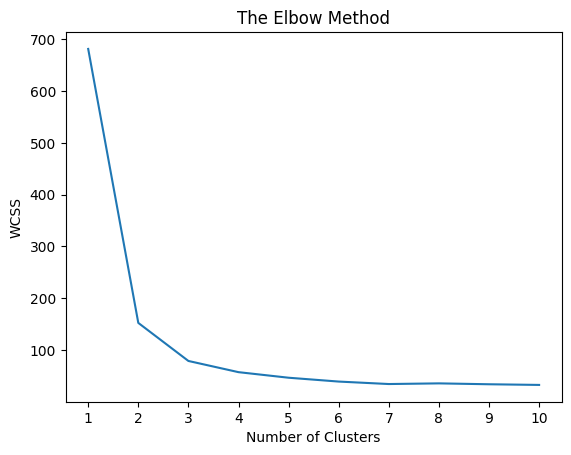

In [24]:
import matplotlib.pyplot as plt

plt.plot(k_range, inertias)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('The Elbow Method')
plt.xticks(k_range)
plt.show()

# Part 2: MNIST Dataset

### Load the Dataset

In [25]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784')

### Split Data into Training and Testing Sets

In [26]:
from sklearn.model_selection import train_test_split

X = mnist.data
y = mnist.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=11)

### Apply StandardScaler

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Get time and score without PCA

In [28]:
import time
from sklearn.linear_model import LogisticRegression

start_without_pca = time.time()
lr = LogisticRegression(solver='lbfgs', max_iter=1000) # getting too many iterations if max_iter isn't set
lr.fit(X_train, y_train)
end_without_pca = time.time()
score_without_pca = lr.score(X_test, y_test)

### Get time and score with PCA

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=11)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

start_with_pca = time.time()
lr_pca = LogisticRegression(solver='lbfgs', max_iter=1000)
lr_pca.fit(X_train_pca, y_train)
end_with_pca = time.time()
score_with_pca = lr_pca.score(X_test_pca, y_test)

### Compare Results

In [30]:
print(f"Without PCA: Time = {end_without_pca - start_without_pca:.2f}s, Accuracy = {score_without_pca:.4f}")
print(f"With PCA:    Time = {end_with_pca - start_with_pca:.2f}s, Accuracy = {score_with_pca:.4f}")

Without PCA: Time = 70.43s, Accuracy = 0.9126
With PCA:    Time = 47.14s, Accuracy = 0.9209
